## Credit Card Fraud Detection using Machine Learning

### Project Overview

- Credit card fraud has become one of the most significant financial security challenges in digital transactions. Due to the large volume of daily transactions, manual fraud detection is inefficient and unable to respond in real time. Machine learning techniques provide the ability to automatically identify suspicious transaction patterns and reduce financial losses.

- This project aims to develop and compare multiple machine learning models for detecting fraudulent credit card transactions using a highly imbalanced transaction dataset. The project focuses not only on prediction accuracy but also on minimizing missed fraud cases through recall-oriented evaluation metrics.

### Project Goals

**The objectives of this project are** 

- Analyze transaction patterns and fraud behaviors
- Understand the challenges of imbalanced fraud datasets
- Perform exploratory data analysis (EDA)
- Build and compare multiple classification models
- Evaluate models using fraud-focused metrics
- Identify important features contributing to fraud detection
- Recommend the most effective model for real-world fraud monitoring

### Dataset Description

- The dataset contains anonymized credit card transaction records, including both legitimate and fraudulent transactions.

**Dataset Characteristics**
- Transactions are labeled as:
    - 0 → Normal transaction
    - 1 → Fraudulent transaction
- Features V1–V28 are anonymized variables transformed using PCA
- Amount represents transaction value
- Time represents elapsed transaction time in seconds

The dataset is highly imbalanced, where fraudulent transactions account for only a very small percentage of total observations.

### Methodology

- The project follows a complete machine learning workflow:

1. Data loading and understanding
2. Data cleaning
3. Exploratory Data Analysis (EDA)
4. Feature engineering and preprocessing
5. Train-test splitting
6. Machine learning model development
7. Model evaluation and comparison
8. Feature importance interpretation
9. Business insights and recommendations

### Data Loading and Understanding

In [1]:
#### Import library
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score, classification_report, precision_score
from sklearn.ensemble import RandomForestClassifier 
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
data = pd.read_csv("dataset/creditcard.csv")
data.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
total_transactions = data.shape[0] #Total rows of transaction history
normal_transactions = data[data['Class']==0]    #Field of normal transactions
count_normal_trans = normal_transactions.shape[0] #number of normal  
fraud_transactions = data[data['Class']==1]     #field of fraud transactions
count_fraud_trans = fraud_transactions.shape[0]     #number of fraud

print("Total number of transactions:", total_transactions)
print("Number of normal transactions", count_normal_trans)
print("Number of fraud transactions:",count_fraud_trans)
print("Fraud transaction rate:", round((count_fraud_trans/total_transactions)*100,2)) #calculate the percentage of fraud: number of fraud trans/ total trans

Total number of transactions: 284807
Number of normal transactions 284315
Number of fraud transactions: 492
Fraud transaction rate: 0.17


In [4]:
#Glimpse the data
print("Credit card data - rows:", data.shape[0])
print("Credit card data - columns:", data.shape[1])
print(data.info())
print(data.head())
print(data.describe())

Credit card data - rows: 284807
Credit card data - columns: 31
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null

- The dataset was imported using Pandas to examine:
    - dataset dimensions
    - data types
    - descriptive statistics
    - fraud distribution

**Key Observations**
- Fraud transactions are extremely rare compared to legitimate transactions.
- The severe imbalance introduces classification bias risks during model training.
- No missing values were detected in the dataset.

**Why This Step Matters**

- Understanding the dataset structure is essential before building predictive models, especially for fraud detection problems where class imbalance significantly affects model performance.

### Data Cleaning

- As description of the dataset above, there is non-null values across features
- Duplicate transaction records were removed from the dataset to improve data quality and prevent redundant observations from influencing model training.

In [7]:
data.drop_duplicates(inplace = True) #drop duplicates
print(data.shape) #Check the data shape again 

(283726, 31)


### Exploratory Data Analysis (EDA)

**Class Distribution Analysis**

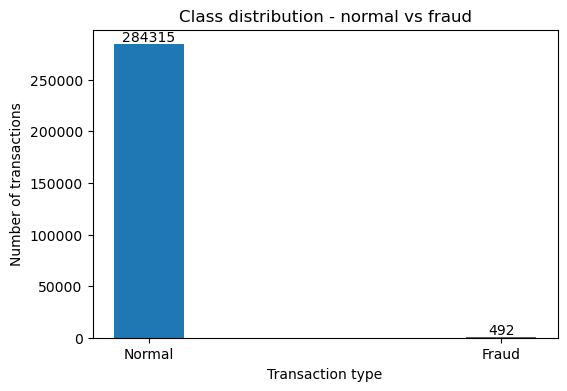

In [5]:
class_counts = data['Class'].value_counts()

plt.figure(figsize=(6,4))
bars = plt.bar(class_counts.index, class_counts.values, width =0.2)
plt.xticks([0,1],['Normal','Fraud'])
plt.xlabel("Transaction type")
plt.ylabel("Number of transactions")
plt.title("Class distribution - normal vs fraud")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        f'{int(yval)}',
        ha='center',
        va='bottom'
    )    
plt.show()

- A bar chart was created to compare the number of normal and fraudulent transactions.
- Findings: Fraud transactions represent only a tiny fraction of the dataset. The dataset is highly imbalanced.
- Implication: Traditional accuracy metrics alone are insufficient because a model can achieve high accuracy while still failing to detect fraud cases.

**Transaction Amount Distribution**

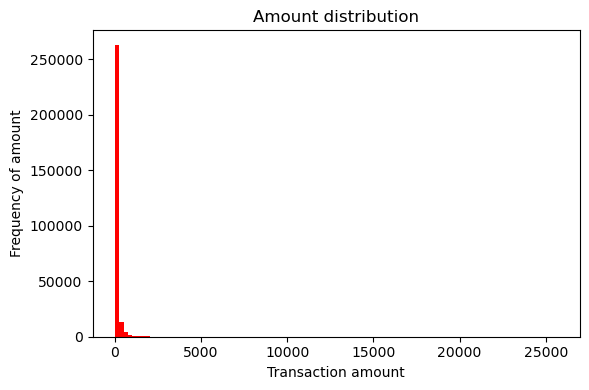

In [6]:
plt.figure(figsize=(6,4))
plt.hist(data["Amount"], bins = 100, color='red')
x_ticks = np.arange(min(data['Amount']), max(data['Amount']), 5000)
plt.xticks(x_ticks)
plt.xlabel('Transaction amount')
plt.ylabel("Frequency of amount")
plt.title("Amount distribution")
plt.tight_layout()
plt.show()

- A histogram was used to analyze transaction amounts.
- Findings: Transaction amounts are heavily right-skewed. Most transactions involve relatively small amounts. A small number of transactions contain extremely large values.
- Implication: Large variance and outliers may negatively affect machine learning performance and require feature scaling.

**Fraud vs Normal Transaction Amounts**

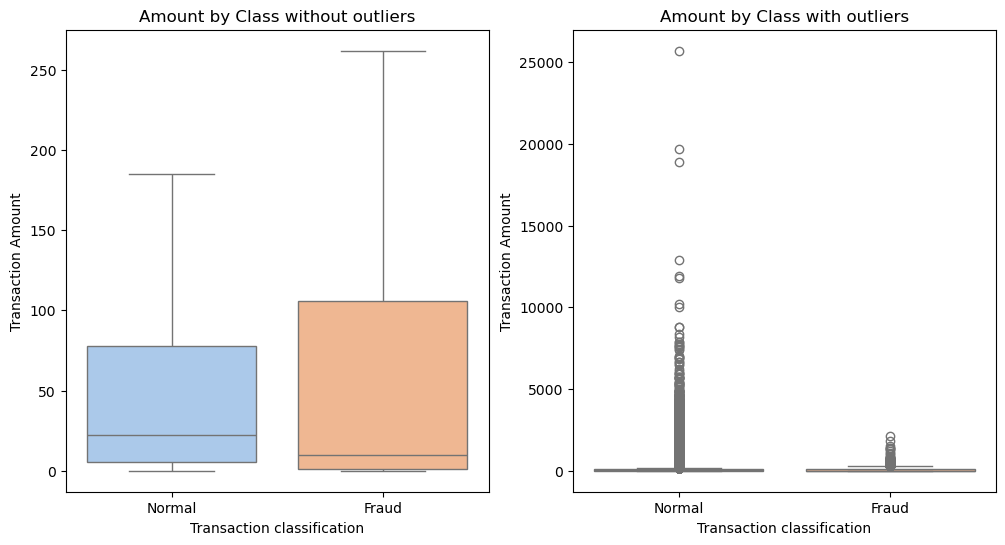

In [10]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,6))

sns.boxplot(
    ax= ax1,
    x="Class",
    y= "Amount",
    hue="Class",
    data = data,
    palette="pastel",
    legend = False,
    showfliers = False
)
ax1.set_title("Amount by Class without outliers")
ax1.set_xlabel("Transaction classification")
ax1.set_ylabel("Transaction Amount")

sns.boxplot(
    ax= ax2,
    x="Class",
    y= "Amount",
    hue="Class",
    data = data,
    palette="pastel",
    showfliers = True,
    legend=False
)
ax2.set_title("Amount by Class with outliers")
ax2.set_xlabel("Transaction classification")
ax2.set_ylabel("Transaction Amount")
ax1.set_xticks([0,1])
ax1.set_xticklabels(["Normal", "Fraud"])
ax2.set_xticks([0,1])
ax2.set_xticklabels(["Normal", "Fraud"])
plt.tight_layout
plt.show()


- Boxplots were used to compare transaction amounts between fraud and legitimate classes.
- Findings: Fraudulent transactions display different amount distributions compared to normal transactions. Outlier behavior is more apparent in fraudulent transactions.
- Implication: Transaction amount may contribute to distinguishing fraudulent behavior.

### Time-Based Fraud Analysis

0          0.000000
1          0.000000
2          0.000278
3          0.000278
4          0.000556
            ...    
284802    47.996111
284803    47.996389
284804    47.996667
284805    47.996667
284806    47.997778
Name: Hour, Length: 283726, dtype: float64


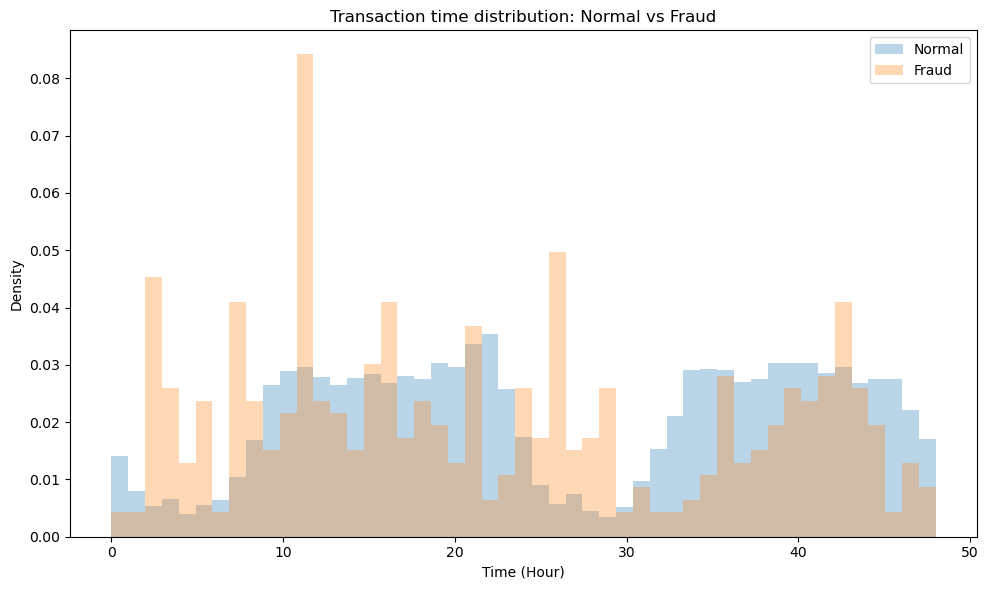

In [11]:
data['Hour'] = data['Time']/3600
print(data['Hour'])

normal_time = data[data['Class']==0]['Hour']
fraud_time = data[data['Class']==1]['Hour']

bins = np.linspace(data['Hour'].min(), data['Hour'].max(),50)
plt.figure(figsize=(10,6))
plt.hist(
    normal_time,
    bins = bins,
    density=True,
    alpha =0.3,
    label="Normal"
)
plt.hist(
    fraud_time,
    bins = bins,
    density=True,
    alpha=0.3,
    label="Fraud"
)
plt.xlabel("Time (Hour)")
plt.ylabel("Density")
plt.title("Transaction time distribution: Normal vs Fraud")
plt.legend()
plt.tight_layout()
plt.show()

- Transaction time was converted into hourly bins to examine temporal patterns. The variations across time hour are observed in the distribution of fraud amount and the density of amount for both transactions are mostly overlapped, showing that time-related features provide limited potential compared to behavioural features.

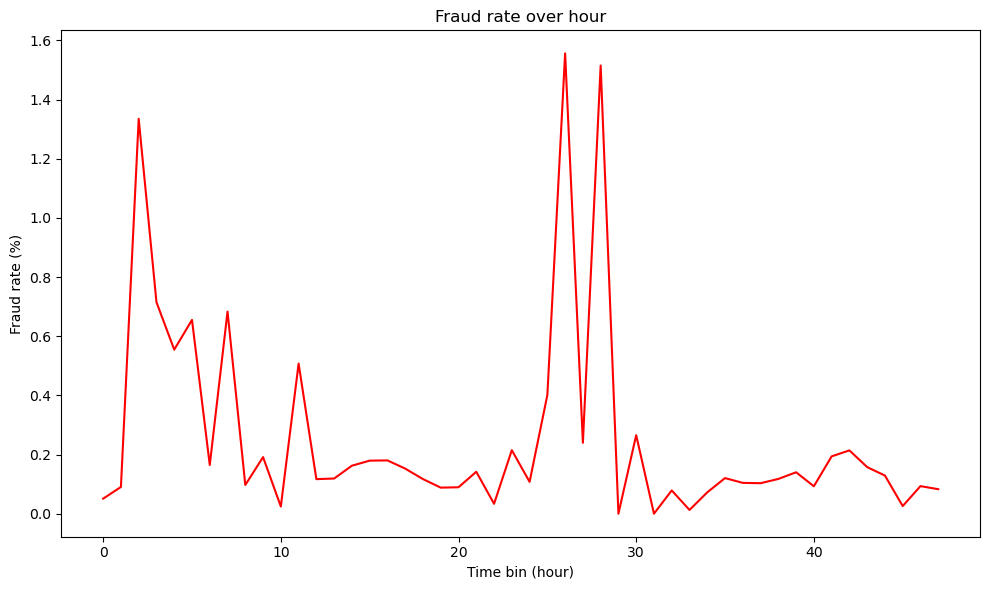

In [12]:
data['Hourbin'] = data['Hour'].astype(int)
total_per_hour = data.groupby("Hourbin").size()
fraud_per_hour = data.groupby("Hourbin")['Class'].sum()
fraud_rate = (fraud_per_hour/total_per_hour)*100

plt.figure(figsize=(10,6))
plt.plot(fraud_rate.index, fraud_rate.values, color='red')
plt.xlabel("Time bin (hour)")
plt.ylabel("Fraud rate (%)")
plt.title("Fraud rate over hour")
plt.tight_layout()
plt.show()

- The fraudulent rate over time is unstable with the number of peaks occuring incoherently. This can be explained by low transaction volumes in these time hours. There is no particular time patterns to predict fraudulent behaviours, meaning that transaction time alone exhibit insufficient potential for fraud detection.

- Consequently, compared to transaction amount and time, behavioural PCA features analysis is required to determine clearer separation between fraudulent and legitimate transactions.

### Correlation Analysis

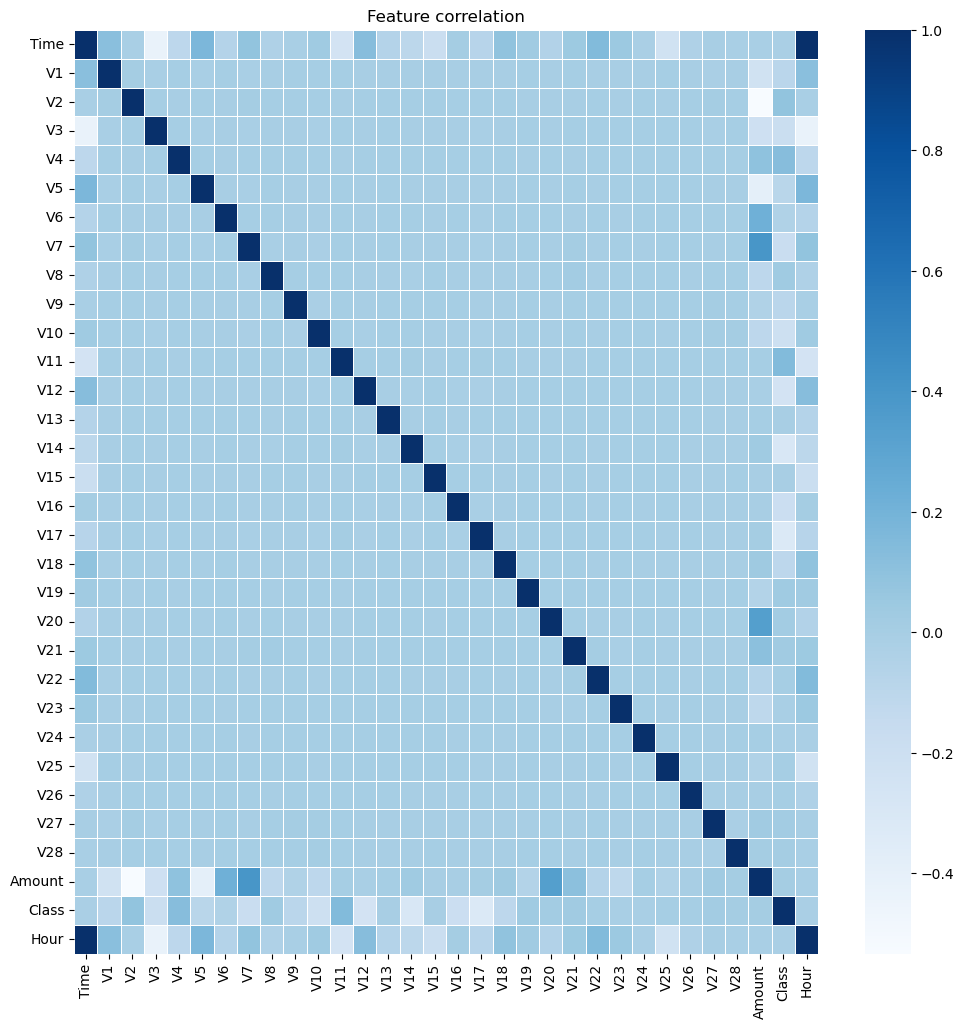

In [14]:
plt.figure(figsize=(12,12))
corr = data.drop('Hourbin', axis = 1).corr()
sns.heatmap(corr, xticklabels=corr.columns, 
            yticklabels=corr.columns, linewidth=0.5,
            cmap='Blues')
plt.title("Feature correlation")
plt.show()

- Correlation heat map shows the limited association between most features. This is expected as the majority of predictors are PCA-transformed components.

### Data Preprocessing

In [7]:
# Feature scaling
X = data.drop('Class', axis=1)
y = data['Class']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Feature scaling**

Scaling is important since it:
- Improves model convergence
- Prevents large-value dominance
- Stabilizes machine learning performance
- This is particularly important for algorithms sensitive to feature magnitude.

### Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Model Development

- Four supervised learning models were implemented:
1. Logistic Regression: baseline model for transaction type classification, used to assess whether linear decision boundaries are sufficient for fraud detection.
2. Decision Tree: simple tree-based benchmark to capture non-linear relationships between characteristics
3. Random Forest: more complex model to improve robustness through ensemble learning and reduce overfitting
4. XGBoost Classifier: the star of this project to handle complex feature interaction in highly imbalanced classification tasks

#### Logistic Regression

In [14]:
log_reg = LogisticRegression(random_state=777)
log_reg.fit(X_train, y_train)
log_reg_prediction = log_reg.predict(X_test)
print('Recall score of the Logistic Regression model is {}'.format(recall_score(y_test, log_reg_prediction)))
print('Precision score of the Logistic Regression is {}'.format(precision_score(y_test, forest_prediction)))
print('F1 score of the Logistic Regression model is {}'.format(f1_score(y_test, log_reg_prediction)))

Recall score of the Logistic Regression model is 0.6428571428571429
Precision score of the Logistic Regression is 0.7155172413793104
F1 score of the Logistic Regression model is 0.7241379310344828


#### Decision Tree

In [15]:
tree = DecisionTreeClassifier(criterion='gini',
                            max_depth=5,
                            random_state=42)
tree.fit(X_train, y_train)
tree_prediction = tree.predict(X_test)
print('Recall score of the Decision Tree model is {}'.format(recall_score(y_test, tree_prediction)))
print('Precision score of the Decision Tree model is {}'.format(precision_score(y_test, forest_prediction)))
print('F1 score of the Decision Tree model is {}'.format(f1_score(y_test, tree_prediction)))
confusion_matrix(y_test, tree_prediction, labels = [0, 1])

Recall score of the Decision Tree model is 0.7755102040816326
Precision score of the Decision Tree model is 0.7155172413793104
F1 score of the Decision Tree model is 0.8306010928961749


array([[56855,     9],
       [   22,    76]])

#### Random Forests

In [12]:
forest = RandomForestClassifier(
    n_estimators=300,       #more trees, more stable
    max_depth = None,       #no depth restriction; overfitting is mitigated by ensemble learning
    min_samples_leaf=30,    #decrease noise, reduce overfitting and smooth prediction
    class_weight='balanced',    #fraud focus
    n_jobs = -1,    
    random_state =42
)
forest.fit(X_train, y_train)
forest_prediction = forest.predict(X_test)
print('Recall score of the Random Forest model is {}'.format(recall_score(y_test, forest_prediction)))
print('Precision score of the Random Forest model is {}'.format(precision_score(y_test, forest_prediction)))

Recall score of the Random Forest model is 0.8469387755102041
Precision score of the Random Forest model is 0.7155172413793104


#### XGBoost Classifier

In [16]:
neg = np.sum(y_train ==0)
pos = np.sum(y_train ==1)
scale_pos_weight = neg/pos
xgb = XGBClassifier(
    n_estimators = 300,
    max_depth = 5,
    learning_rate =0.5,
    subsample = 0.8,
    colsample_bytree = 0.8,
    reg_lambda =1.0,
    scale_pos_weight = scale_pos_weight,
    objective ='binary:logistic',
    eval_metric ='logloss',
    n_jobs=-1,
    random_state = 42
)

xgb.fit(X_train,y_train)
xgb_predict = xgb.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_predict))
print("Precision score of the XGB model is {}".format(precision_score(y_test, xgb_predict)))
print("Recall score of the XGB model is {}".format(recall_score(y_test, xgb_predict)))

Confusion Matrix:
 [[56853    11]
 [   16    82]]
Precision score of the XGB model is 0.8817204301075269
Recall score of the XGB model is 0.8367346938775511


#### Metric result table and visualisation

In [17]:
#Metric results table
results = []

models = {
    "Logistic Regression": log_reg_prediction,
    "Decision Tree": tree_prediction,
    "Random Forest": forest_prediction,
    "XGBoost Classifier": xgb_predict
}

for model_name, y_pred in models.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 score": f1_score(y_test, y_pred)
    })

metrics_df = pd.DataFrame(results)
print(metrics_df)

                 Model  Accuracy  Precision    Recall  F1 score
0  Logistic Regression  0.999157   0.828947  0.642857  0.724138
1        Decision Tree  0.999456   0.894118  0.775510  0.830601
2        Random Forest  0.999157   0.715517  0.846939  0.775701
3   XGBoost Classifier  0.999526   0.881720  0.836735  0.858639


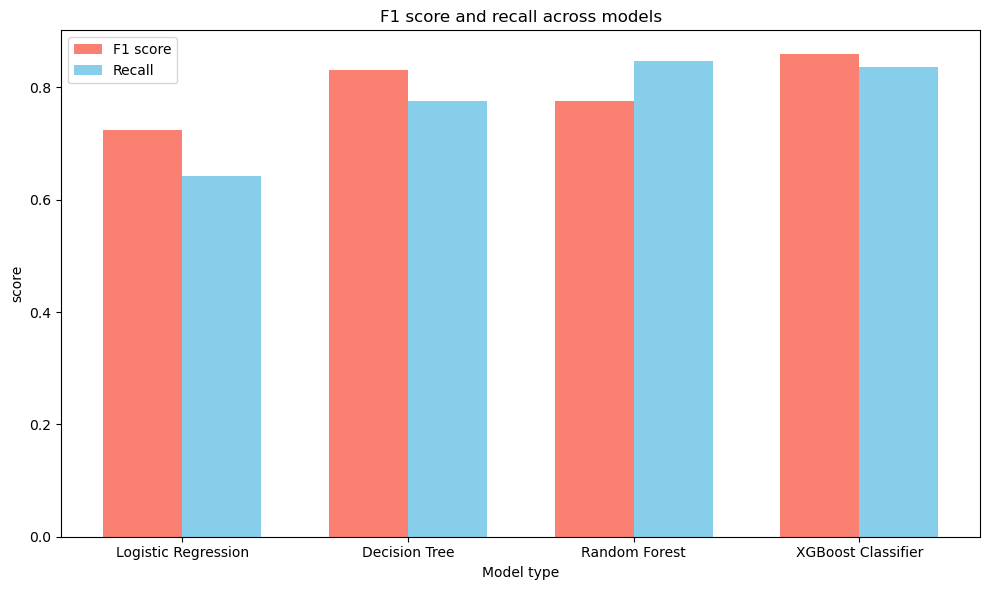

In [18]:
model = metrics_df['Model']
f1_score = metrics_df['F1 score']
recall_score = metrics_df['Recall']

x = np.arange(len(model))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, f1_score, width, label='F1 score', color = 'salmon')
plt.bar(x + width/2, recall_score, width, label='Recall', color = 'skyblue')

plt.xlabel("Model type")
plt.ylabel("score")
plt.title("F1 score and recall across models")
plt.xticks(x, models)
plt.legend()
plt.tight_layout()
plt.show()

- As expected, accuracy scores are nearly 100 in all models, showing that accuracy metric is overfiiting to evaluate the best model in this case.
- XGBoost Classifier achieve the highest precision and F1 score, indicating the best balance and accurate model for fraud detection.
- Although Random Forest has the higher recall score, its precision is the lowest number. As a result, XGBoost provides a superior balance between precision and recall

### Confusion matrix between Random Forest vs XGBoost

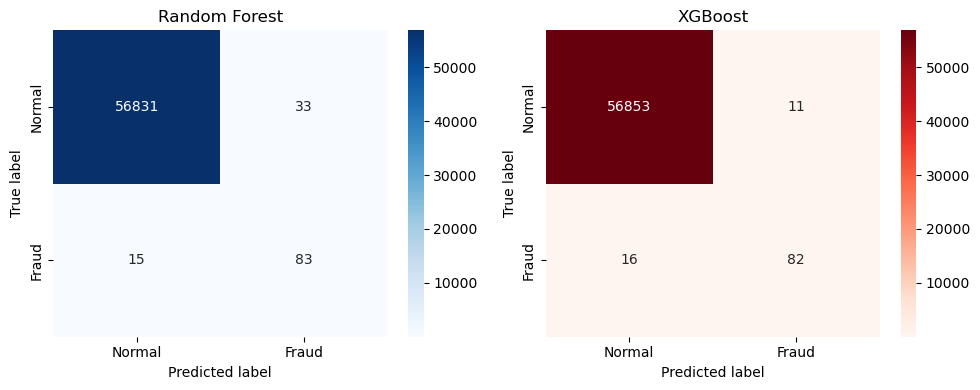

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Tính confusion matrix
cm1 = confusion_matrix(y_test, forest_prediction)
cm2 = confusion_matrix(y_test, xgb_predict)

# Tạo subplot
fig, axes = plt.subplots(1, 2, figsize=(10,4))

# Random Forest
sns.heatmap(
    cm1,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal','Fraud'],
    yticklabels=['Normal','Fraud'],
    ax=axes[0]
)
axes[0].set_title('Random Forest')
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')

# XGBoost
sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Normal','Fraud'],
    yticklabels=['Normal','Fraud'],
    ax=axes[1]
)
axes[1].set_title('XGBoost')
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')

plt.tight_layout()
plt.show()

- Random Forest identified one additional fraudulent transaction compared to XGBoost (83 vs 82 true positives). However, this small improvement came at the cost of substantially more false positives, incorrectly flagging 33 legitimate transactions as fraud compared to only 11 for XGBoost.

- Although XGBoost missed one extra fraud case, it significantly reduced unnecessary fraud alerts while maintaining a nearly identical fraud detection rate. This indicates that XGBoost achieves a more efficient balance between fraud detection performance and operational investigation cost.

### Feature importance

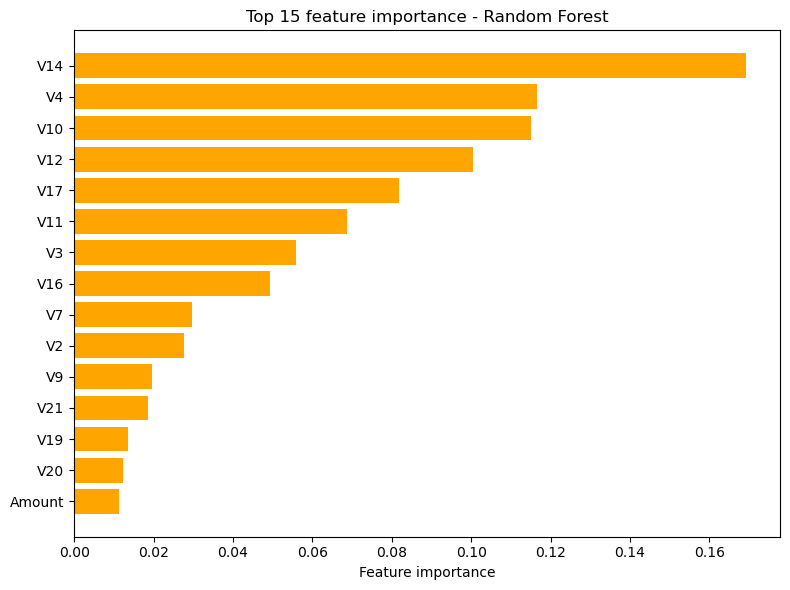

In [20]:
#Feature importance
#1. Random Forest
feature_names = data.drop(columns=['Class']).columns
rf_importance = forest.feature_importances_
rf_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance':rf_importance
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(8,6))
plt.barh(rf_imp_df['Feature'], rf_imp_df['Importance'], color = 'orange')
plt.gca().invert_yaxis()
plt.xlabel("Feature importance")
plt.title("Top 15 feature importance - Random Forest")
plt.tight_layout()
plt.show()

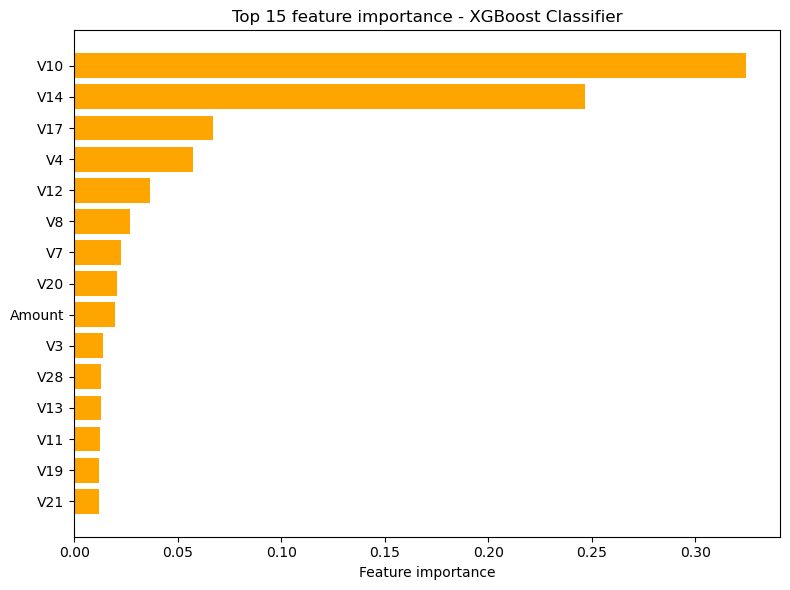

In [21]:
#2. XGBoost
xgb_importance = xgb.feature_importances_
xgb_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_importance
}).sort_values(by='Importance', ascending = False).head(15)
plt.figure(figsize=(8,6))
plt.barh(xgb_imp_df['Feature'], xgb_imp_df['Importance'], color = 'orange')
plt.gca().invert_yaxis()
plt.xlabel("Feature importance")
plt.title("Top 15 feature importance - XGBoost Classifier")
plt.tight_layout()
plt.show()

- Both Random Forest and XGBoost identify V14 as the most influential feature for fraud detection, highlighting its strong predictive relevance across ensemble models.
- Additional behavioural features such as V4, V10, V12, V11, and V9 also contribute significantly to classification performance, indicating that fraud detection relies on multiple transaction behaviour patterns rather than a single variable.
- Random Forest distributes feature importance more broadly across several predictors, suggesting that the model evaluates fraud using a combination of behavioural characteristics.
- In contrast, XGBoost assigns substantially greater importance to V14, demonstrating its ability to prioritize highly informative variables and optimize information gain more aggressively.
- Transaction-related variables such as Time and Amount are not among the top-ranked predictors, implying that behavioural PCA-transformed features provide stronger discriminatory power for fraud detection.
- Overall, the feature importance analysis suggests that abnormal behavioural patterns are more effective for identifying fraud than basic transaction magnitude or timing information.

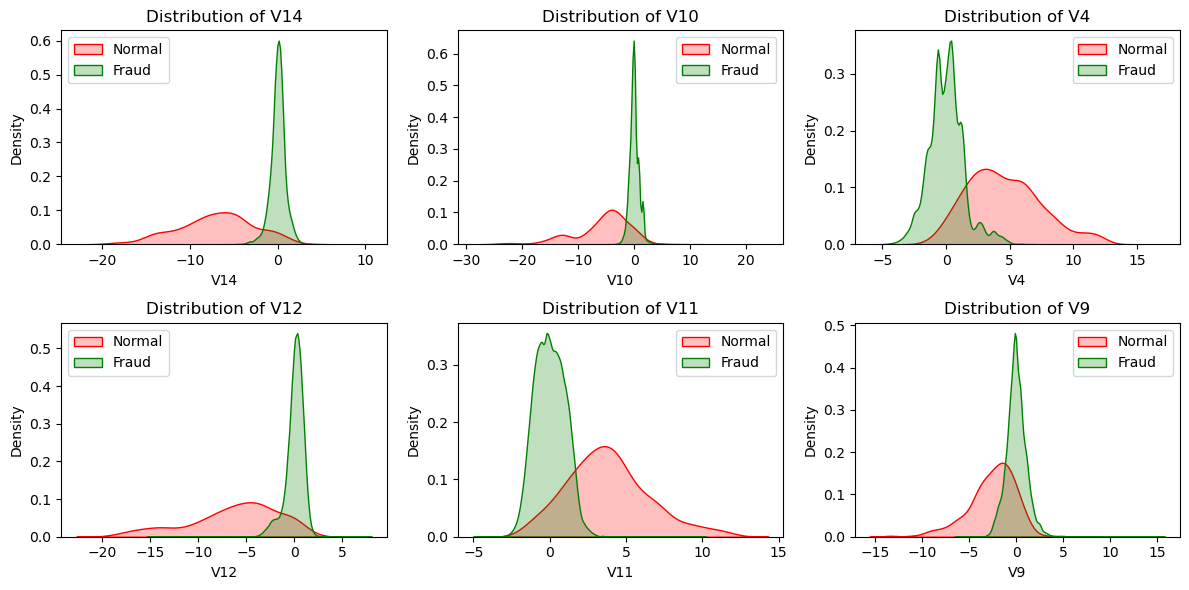

In [22]:
#Feature distribution - KDE
top_features = ['V14','V10','V4','V12','V11','V9']
plt.figure(figsize=(12,6))

for i, feature in enumerate(top_features,1):
    plt.subplot(2,3,i)
    sns.kdeplot(
        data=data,
        x=feature,
        hue="Class",
        fill=True,
        common_norm=False,
        palette={0:"green",1:'red'}
    )
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend(labels=['Normal','Fraud'])
plt.tight_layout()
plt.show()

- KDE plots reveal clear distribution differences between fraudulent and legitimate transactions across several high-importance features.
- Features such as V14 and V10 show the strongest separation between fraud and normal classes, with minimal overlap and sharper fraud density peaks, indicating high predictive capability.
- Fraudulent transactions generally exhibit narrower and more concentrated distributions, whereas legitimate transactions are broader and more dispersed.
- Features including V4, V12, and V11 also demonstrate noticeable class separation, reinforcing their contribution to fraud classification models.
- In contrast, V9 shows greater overlap between fraud and normal distributions, suggesting weaker discriminatory power compared to other selected variables.
- The observed distribution patterns validate the effectiveness of PCA-transformed behavioural features for fraud detection and support their importance in ensemble learning models.
- Overall, behavioural transaction patterns appear substantially more informative than raw transaction attributes such as transaction amount or time.

### Key findings

- Fraud transactions are extremely rare, creating severe class imbalance.
- Ensemble learning models outperform simpler baseline methods.
- XGBoost provides the strongest fraud detection performance.
- Certain anonymized variables contribute heavily to fraud classification.
- Evaluation focusing on Recall and Precision is essential for fraud detection systems

### Business recommendations

- Deploy ensemble-based fraud detection models such as XGBoost in production systems
- Prioritize recall to minimize undetected fraud cases
- Implement real-time fraud monitoring during high-risk transaction periods
- Continuously retrain models to adapt to evolving fraud behavior
- Balance the trade-off between false positives and false negatives to optimize investigation costs and fraud prevention effectiveness.
- Combine machine learning predictions with rule-based monitoring systems for improved reliability